# **Exploratory Data Analysis**

[Обзор датасета](#Data-overview)

[Загрузка данных](#Data-loading)

- [SeriousDlqin2yrs](#SeriousDlqin2yrs)
- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [age](#age)
- [DebtRatio](#DebtRatio)
- [MonthlyIncome](#MonthlyIncome)
- [NumberOfDependents](#NumberOfDependents)
- [NumberOfOpenCreditLinesAndLoans](#NumberOfOpenCreditLinesAndLoans)
- [NumberRealEstateLoansOrLines](#NumberRealEstateLoansOrLines)
- [NumberOfTime30-59DaysPastDueNotWorse](#NumberOfTime30-59DaysPastDueNotWorse)
- [NumberOfTime60-89DaysPastDueNotWorse](#NumberOfTime60-89DaysPastDueNotWorse)
- [NumberOfTimes90DaysLate](#NumberOfTimes90DaysLate)
  
[Выводы](#Insights)

---

## Data overview

**150'000** клиентов банка

Целевая переменная:

- `SeriousDlqin2yrs` (0 или 1) — имел ли заемщик серьезную просрочку (90 дней или более) в течение последних 2 лет.

Признаки:

- `age` (целое число) — возраст заемщика в годах.

- `MonthlyIncome` (вещественное число) — ежемесячный доход заемщика.

- `NumberOfDependents` (целое число) — количество иждивенцев в семье, не включая самого заемщика (супруг, дети и др.).

- `RevolvingUtilizationOfUnsecuredLines` (процент) — коэффициент использования необеспеченных кредитных линий. Рассчитывается как общий баланс по кредитным картам и персональным кредитным линиям (за исключением недвижимости и рассрочек, таких как автокредиты), деленный на сумму кредитных лимитов.

- `DebtRatio` (процент) — отношение долговой нагрузки к доходу. Включает ежемесячные платежи по долгам, алименты и расходы на жизнь, деленные на ежемесячный доход.

- `NumberOfOpenCreditLinesAndLoans` (целое число) — общее количество открытых кредитов (например, автокредиты или ипотека) и кредитных линий (например, кредитные карты).

- `NumberRealEstateLoansOrLines` (целое число) — количество ипотечных кредитов и кредитов под залог недвижимости, включая кредитные линии под залог собственного капитала.

- `NumberOfTime3059DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 30 до 59 дней (но не хуже) за последние 2 года.

- `NumberOfTime60-89DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 60 до 89 дней (но не хуже) за последние 2 года.

- `NumberOfTimes90DaysLate` (целое число) — количество случаев, когда заемщик имел просрочку 90 дней или более.

## Hypotheses

1. [\[~\]](#\~-Гипотеза-1-частично-подтверждена) Чем старше заёмщик, тем ниже риск дефолта, но только до определённого, очень пожилого возраста.
2. [\[~\]](#\~-Гипотеза-2-частично-подтверждена) С ростом дохода риск дефолта уменьшается.
3. Вероятности дефолта прямо пропорциональны:
    - [\[~\]](#\~-Гипотеза-3.1-частично-подтверждена) `NumberOfDependents`
    - [\[✔\]](#✔-Гипотеза-3.2-подтверждена) `RevolvingUtilizationOfUnsecuredLines`
    - [\[✘\]](#✘-Гипотеза-3.3-опровергнута) `DebtRatio`
    - [\[✘\]](#✘-Гипотеза-3.4-опровергнута) `NumberOfOpenCreditLinesAndLoans`
    - [\[~\]](#\~-Гипотеза-3.5-частично-подтверждена) Признаки `NumberOfTime...`
4. [\[✔\]](#✔-Гипотеза-4-подтверждена) Распределения плотностей нулевых и пропущенных значений `MonthlyIncome` коррелируют 
5. [\[✔\]](#✔-Гипотеза-5-подтверждена) Наличие небольшого количества кредитов на недвижимость (`NumberRealEstateLoansOrLines`) снижает риск дефолта, а большого — повышает.
6. [\[✔\]](#✔-Гипотеза-6-подтверждена) Количество просрочек (`NumberOfTime...`) сильно коррелирует с риском дефолта.

[✔] - подтверждена;
[~] - частично подтверждена;
[✘] - опровергнута

---

## Data loading

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
sys.path.append('../')

from src import *

seed = 42
np.random.seed(seed)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
train = pd.read_csv('../data/raw/cs-training.csv', index_col='Unnamed: 0')

## `SeriousDlqin2yrs`

In [3]:
train.SeriousDlqin2yrs.describe()

count    150000.000000
mean          0.066840
std           0.249746
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64

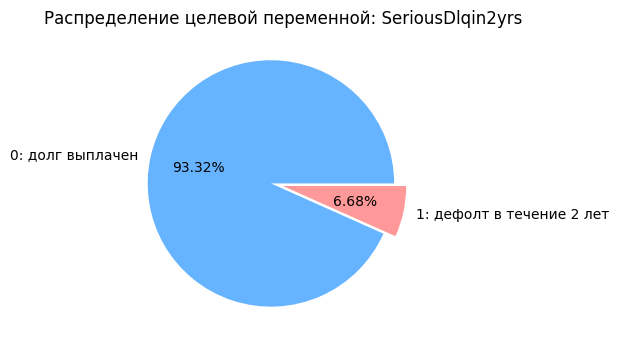

In [4]:
counts = train['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(4, 4))
explode = (0.1, 0)

plt.pie(counts, autopct='%.2f%%', labels=['0: долг выплачен', '1: дефолт в течение 2 лет'],
        colors=['#66b3ff', '#ff9999'], explode=explode)
plt.title('Распределение целевой переменной: SeriousDlqin2yrs')
plt.show()

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

Имеем пропуски значений `MonthlyIncome` и `NumberOfDependents`

In [6]:
print(f"Пропусков в MonthlyIncome:      {train.MonthlyIncome.isna().mean() * 100:.2f}%")
print(f"Пропусков в NumberOfDependents: {train.NumberOfDependents.isna().mean() * 100:.2f}%")

Пропусков в MonthlyIncome:      19.82%
Пропусков в NumberOfDependents: 2.62%


In [7]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## `RevolvingUtilizationOfUnsecuredLines`

In [8]:
train.RevolvingUtilizationOfUnsecuredLines.describe(percentiles=[.25, .5, .75, .95, .99, .997])

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
95%           1.000000
99%           1.092956
99.7%         1.760802
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

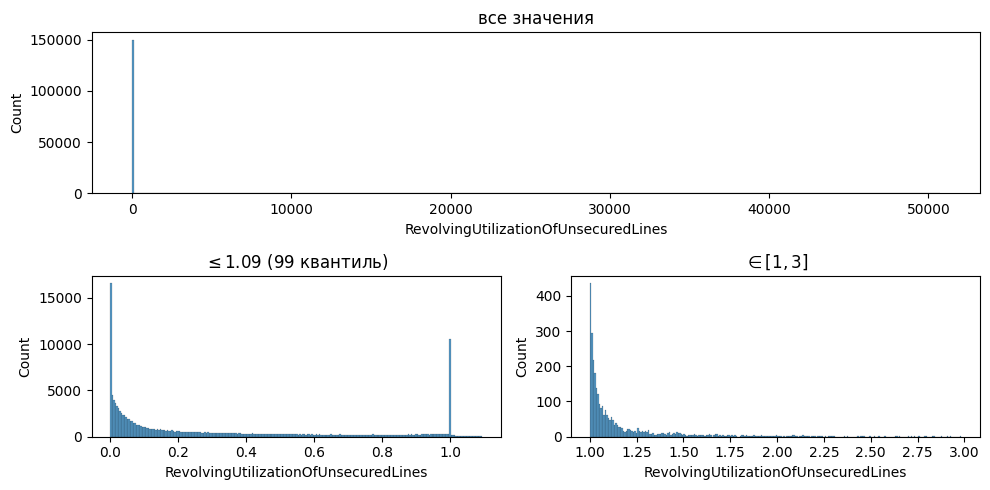

In [9]:
fix, axs = plt.subplot_mosaic([
                                ['top', 'top'],
                                ['bottom-left', 'bottom-right'],
                              ],
                              figsize=(10, 5))

quantile_99 = train.RevolvingUtilizationOfUnsecuredLines.quantile(0.99)

sns.histplot(data=train,
             x='RevolvingUtilizationOfUnsecuredLines',
             bins=500,
             ax=axs['top']);
axs['top'].set_title('все значения')

sns.histplot(data=train.loc[train.RevolvingUtilizationOfUnsecuredLines.le(quantile_99)],
             x='RevolvingUtilizationOfUnsecuredLines',
             bins=250,
             ax=axs['bottom-left']);
axs['bottom-left'].set_title(rf'$\leq {quantile_99:.2f}$ (99 квантиль)')

sns.histplot(data=train.loc[train.RevolvingUtilizationOfUnsecuredLines.between(1, 3)],
             x='RevolvingUtilizationOfUnsecuredLines',
             bins=250,
             ax=axs['bottom-right']);
axs['bottom-right'].set_title(r'$\in [1, 3]$')

plt.tight_layout()

In [10]:
with pd.option_context('display.precision', 12):
    print('Наиболее частые значения:\n')
    print(train['RevolvingUtilizationOfUnsecuredLines'].value_counts().head(5))

Наиболее частые значения:

RevolvingUtilizationOfUnsecuredLines
0.00000000    10878
0.99999990    10256
1.00000000       17
0.95009980        8
0.71314741        6
Name: count, dtype: int64


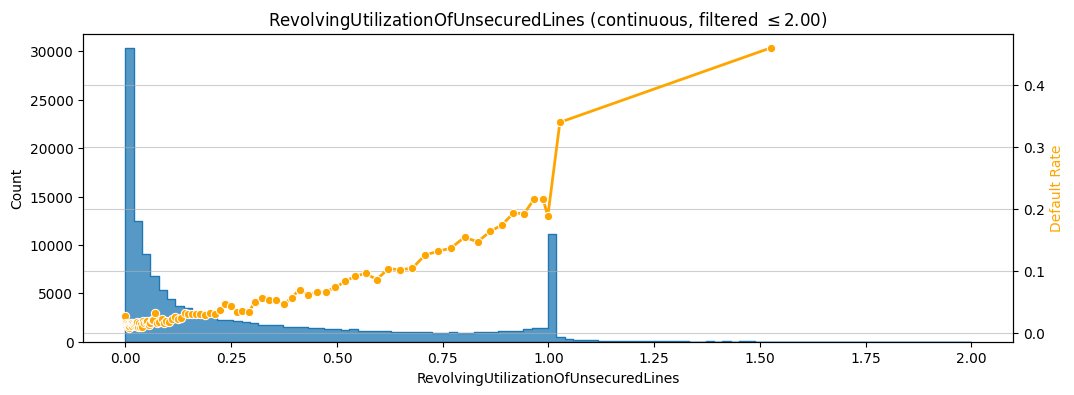

In [11]:
plot_feature_analysis(train, 'RevolvingUtilizationOfUnsecuredLines',
                      n_quantiles=100, max_value=2, figsize=(12, 4));

#### **✔ Гипотеза 3.2 подтверждена**

Полученное распределение подтверждает гипотезу 3.2, риск дефолта действительно имеет прямую зависимость от использования необеспеченных кредитных линий.

In [12]:
RUUL_bins = np.concatenate((np.linspace(0, 1, 11),
                            [1.5, 2, 100],
                            np.arange(1000, train.RevolvingUtilizationOfUnsecuredLines.max()+1, 1000),
                            [train.RevolvingUtilizationOfUnsecuredLines.max()]))

train['RUUL_bin'] = pd.cut(train.RevolvingUtilizationOfUnsecuredLines,
                           bins=RUUL_bins,
                           duplicates='drop',
                           include_lowest=True)

RUUL_stats = train.groupby('RUUL_bin').agg(DefaultRisk=('SeriousDlqin2yrs', 'mean'))

RUUL_stats['NumberOfClients'] = train.RUUL_bin.value_counts()
RUUL_stats.iloc[:30]

,DefaultRisk,NumberOfClients
RUUL_bin,,
"(-0.001, 0.1]",0.018104,64404
"(0.1, 0.2]",0.027795,17305
"(0.2, 0.3]",0.037054,11173
"(0.3, 0.4]",0.052704,8671
"(0.4, 0.5]",0.065512,7159
"(0.5, 0.6]",0.088493,6057
"(0.6, 0.7]",0.103918,5283
"(0.7, 0.8]",0.136241,4815
"(0.8, 0.9]",0.160348,5064


## `age`

In [13]:
train.age.describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

In [14]:
age_stats = train.groupby('age').agg(count=('age', 'size'), DefaultRisk=('SeriousDlqin2yrs', 'mean')).reset_index()

age_stats.loc[age_stats.age <= 30]

,age,count,DefaultRisk
0,0,1,0.000000
1,21,183,0.071038
2,22,434,0.082949
3,23,641,0.109204
4,24,816,0.120098
5,25,953,0.126967
6,26,1193,0.123219
7,27,1338,0.124066
8,28,1560,0.131410
9,29,1702,0.105170


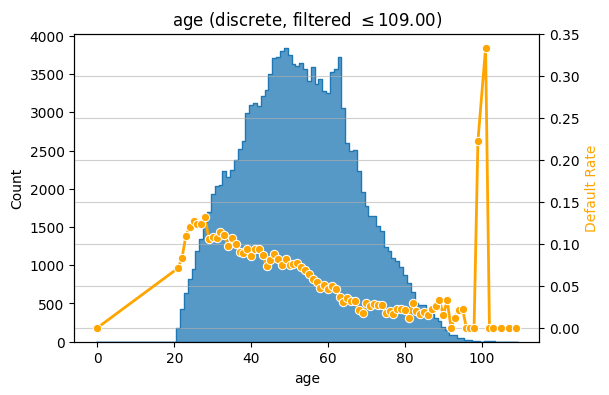

In [15]:
plot_feature_analysis(train, 'age',
                      n_quantiles=40, discrete=True);

Пик риска при возрасте около 100 лет, обусловлен малой численностью респондентов и случайным всплеском в данных.

#### **~ Гипотеза 1 частично подтверждена**

Полученное распределение частично подтверждает первую гипотезу, риск дефолта действительно уменьшается с возрастом клиентов, но до возраста в ~28 лет рияск растет.

In [16]:
train.age.nsmallest(5)

65696     0
1732     21
2792     21
3369     21
3717     21
Name: age, dtype: int64

In [17]:
train.age.nlargest(5)

105791    109
138292    109
40008     107
56762     105
19885     103
Name: age, dtype: int64

In [18]:
age_stats = train.groupby('age').agg(count=('age', 'size'), DefaultRisk=('SeriousDlqin2yrs', 'mean')).reset_index()

age_stats.loc[age_stats.age >= 90]

,age,count,DefaultRisk
70,90,198,0.015152
71,91,154,0.032468
72,92,93,0.000000
73,93,87,0.011494
74,94,47,0.021277
75,95,45,0.022222
76,96,18,0.000000
77,97,17,0.000000
78,98,6,0.000000
79,99,9,0.222222


## `DebtRatio`

In [19]:
train.DebtRatio.describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

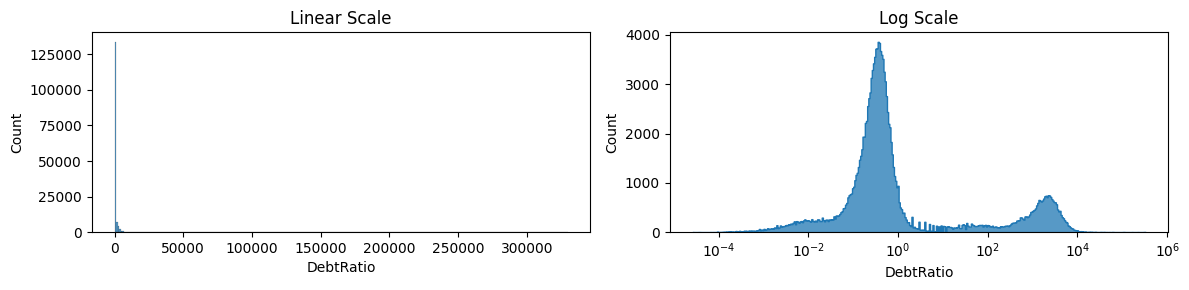

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

sns.histplot(data=train, x='DebtRatio', bins=300, ax=axs[0]);
sns.histplot(data=train, x='DebtRatio', element='step', log_scale=True, ax=axs[1]);

axs[1].set_title('Log Scale')
axs[0].set_title('Linear Scale')

plt.tight_layout()
plt.show()

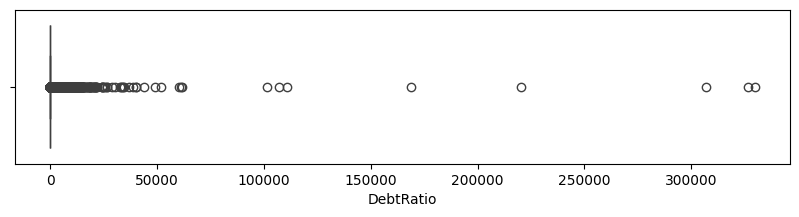

In [21]:
plt.figure(figsize=(10, 2))
sns.boxplot(train, x='DebtRatio')
plt.show()

In [22]:
train['DebtRatio_q_bin'] = pd.qcut(train.DebtRatio, q=20, duplicates='drop')
train.groupby('DebtRatio_q_bin').agg(Count=('DebtRatio', 'size'),
                                     MonthlyIncome_mean=('MonthlyIncome', 'mean'),
                                     DefaultRisk=('SeriousDlqin2yrs', 'mean'))

,Count,MonthlyIncome_mean,DefaultRisk
DebtRatio_q_bin,,,
"(-0.001, 0.00433]",7501,7612.988774,0.058126
"(0.00433, 0.0309]",7499,7258.774637,0.049473
"(0.0309, 0.0864]",7500,7432.922400,0.070800
"(0.0864, 0.134]",7500,7412.272933,0.065600
"(0.134, 0.175]",7500,7263.369467,0.060133
"(0.175, 0.214]",7500,7664.277467,0.060533
"(0.214, 0.251]",7500,7601.900267,0.053333
"(0.251, 0.287]",7500,7642.118400,0.054800
"(0.287, 0.325]",7500,7431.823600,0.052667


За пиком риска на интервале (0.868, 4.0] следует падение заработной платы почти до нуля

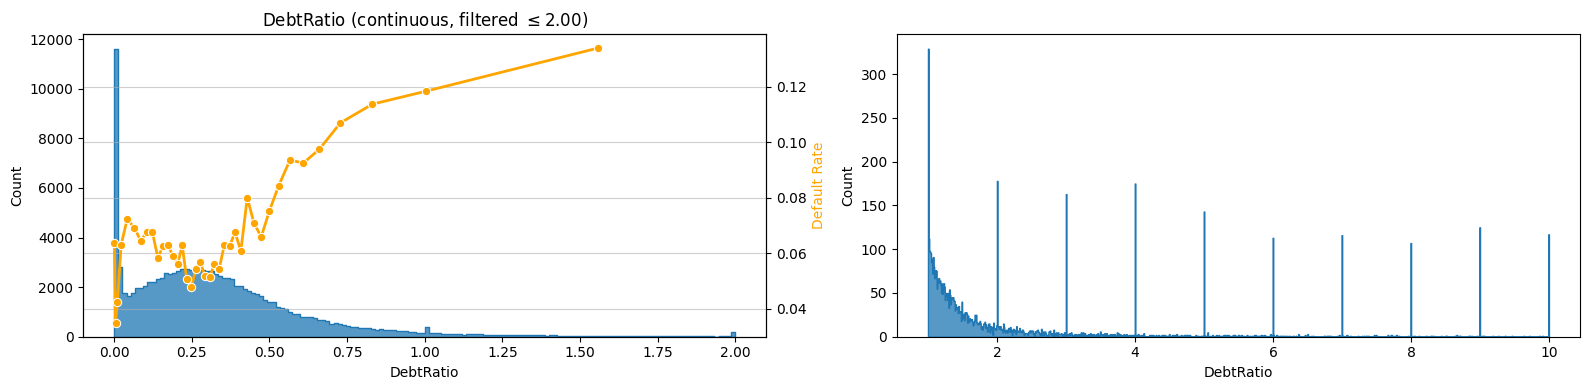

In [23]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 4))

plot_feature_analysis(train, 'DebtRatio',
                      max_value=2, ax=ax1)

sns.histplot(x=train.loc[train.DebtRatio.between(left=1, right=10), 'DebtRatio'],
             element='step', ax=ax3, bins=1000)

plt.tight_layout()

#### **✘ Гипотеза 3.3 опровергнута**

Полученное распределение опровергает гипотезу 3.3. Наименьший риск дефолта наблюдается у клиентов с околонулевым и умеренным значением `DebtRatio` (порядка ~25%).

In [24]:
train.DebtRatio.value_counts().nlargest(7)

DebtRatio
0.0    4113
1.0     229
4.0     174
2.0     170
3.0     162
5.0     143
9.0     125
Name: count, dtype: int64

In [25]:
train['DebtRatio_bin'] = pd.cut(train.DebtRatio, duplicates='drop', bins=np.arange(0, 329665, 2), include_lowest=True)
train['DebtRatio_bin_left'] = train.DebtRatio_bin.map(lambda x: x.left)
train['MonthlyIncome_mean_DR_bin'] = train.groupby('DebtRatio_bin_left').MonthlyIncome.transform('mean')

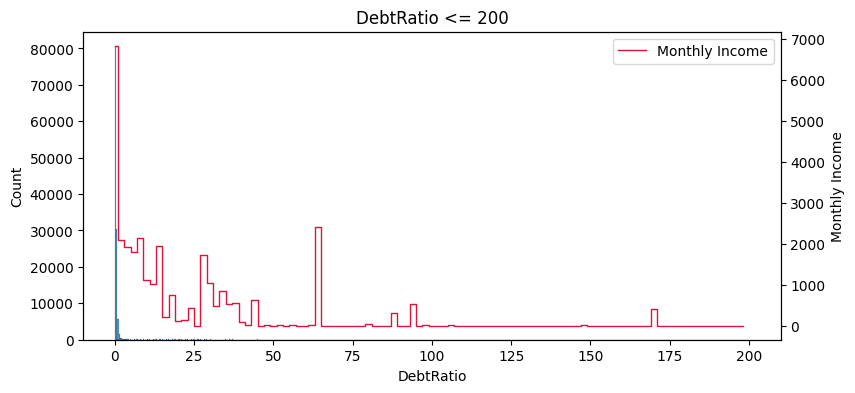

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 4))

sns.histplot(data=train.loc[train.DebtRatio.le(200)], x='DebtRatio', bins=500, ax=ax1, label='Count')

ax2 = ax1.twinx()

sns.lineplot(
    data=train.loc[train.DebtRatio.le(200)], 
    x='DebtRatio_bin_left', 
    y='MonthlyIncome_mean_DR_bin', 
    errorbar=None,
    drawstyle='steps-mid',
    color='crimson',
    linewidth=1,
    ax=ax2,
    label='Monthly Income'
)

ax1.grid(False)
ax2.set_title('DebtRatio <= 200');
ax2.set_ylabel('Monthly Income');

In [27]:
train.loc[train.DebtRatio.between(50, 75) & train.MonthlyIncome.ge(100)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
55487,0,0.228582,65,0,65.712209,7223.0,14,0,0,0,0.0,"(0.2, 0.3]","(4.0, 269.15]","(64.0, 66.0]",64.0,2407.666667
61020,0,0.068091,72,0,62.138614,100.0,17,0,2,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(62.0, 64.0]",62.0,16.142857


Пик около `DebtRatio ≈ 65` обусловлен наличием респондента с высокой (7223) зарплатой и малой плотностью данных

In [28]:
threshold = 50

DR_pct_gt_60   = 100 * (1 - train.DebtRatio.rank(pct=True).loc[train.DebtRatio == threshold].iloc[0])
DR_MonInc_le_1 = 100 * (train.loc[train.DebtRatio.gt(threshold) & (train.MonthlyIncome.le(0) | train.MonthlyIncome.isna()), 'MonthlyIncome'].isna().shape[0] / train.shape[0])

print(f"Процент клиентов с DebtRatio > {threshold}: {DR_pct_gt_60:.2f}%")
print(f"Из них с доходом == 0 или NaN: {100 * DR_MonInc_le_1 / DR_pct_gt_60:.2f}%")

Процент клиентов с DebtRatio > 50: 17.30%
Из них с доходом == 0 или NaN: 97.96%


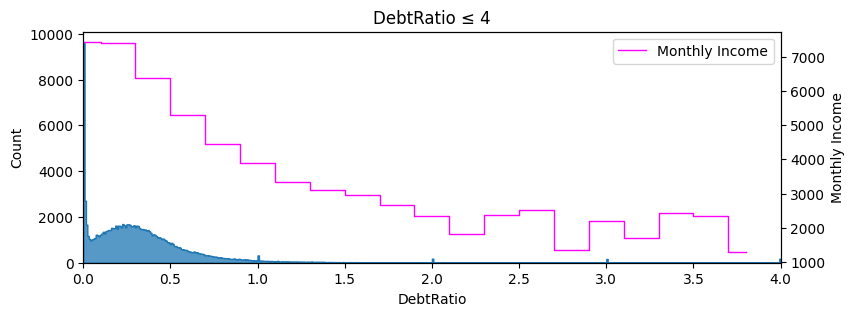

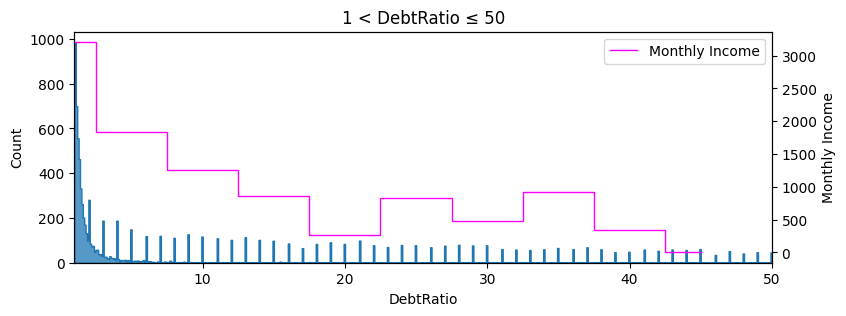

In [29]:
def plot_debt_ratio_vs_income(
    df: pd.DataFrame,
    *,
    mask: pd.Series,
    bin_step: float,
    title: str,
    hist_bins: int = 500,
    xlim: tuple[float, float] | None = None,
    figsize: tuple[int, int] = (9, 3),
):
    d = df.loc[mask, ["DebtRatio", "MonthlyIncome"]].copy()

    max_edge = df["DebtRatio"].max()
    edges = np.r_[np.arange(0, 100, bin_step), max_edge]

    bins = pd.cut(d["DebtRatio"], bins=edges, include_lowest=True, duplicates="drop")

    mean_income = (
        d.groupby(bins, observed=True)["MonthlyIncome"]
        .mean()
        .rename("MonthlyIncome_mean")
        .reset_index()
    )

    mean_income["DebtRatio_bin_left"] = mean_income[bins.name].apply(lambda iv: iv.left)

    fig, ax1 = plt.subplots(figsize=figsize)

    sns.histplot(
        data=d,
        x="DebtRatio",
        bins=hist_bins,
        ax=ax1,
        element='step',
        label="Count",
    )

    ax2 = ax1.twinx()
    sns.lineplot(
        data=mean_income,
        x="DebtRatio_bin_left",
        y="MonthlyIncome_mean",
        errorbar=None,
        drawstyle="steps-mid",
        color="magenta",
        linewidth=1,
        ax=ax2,
        label="Monthly Income",
    )

    if xlim is not None:
        ax1.set_xlim(*xlim)

    ax1.grid(False)
    ax2.set_title(title)
    ax2.set_ylabel("Monthly Income")
    plt.show()


plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].le(4),
    bin_step=0.2,
    title="DebtRatio ≤ 4",
    xlim=(0, 4),
)

plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].gt(1) & train["DebtRatio"].le(50),
    bin_step=5,
    title="1 < DebtRatio ≤ 50",
    xlim=(1, 50),
)

In [30]:
median_income = 10000#train.MonthlyIncome.median()
print(f"Медианная зарплата: {median_income:.2f}")

print()

rich_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (1, 25]: {100 * rich_pct_1_25:.2f}%")
nowork_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & (train.MonthlyIncome.eq(0) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп == 0 или NaN на DebtRatio (1, 25]: {100 * nowork_pct_1_25:.2f}%")

print()

rich_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (25, 50]: {100 * rich_pct_25_50:.2f}%")
nowork_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & (train.MonthlyIncome.eq(0) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп == 0 или NaN на DebtRatio (25, 50]: {100 * nowork_pct_25_50:.2f}%")

train.loc[train.DebtRatio.between(20, 40) & train.MonthlyIncome.ge(2000)]

Медианная зарплата: 10000.00

Зп больше медианы на DebtRatio (1, 25]: 1.64%
Зп == 0 или NaN на DebtRatio (1, 25]: 34.75%

Зп больше медианы на DebtRatio (25, 50]: 0.19%
Зп == 0 или NaN на DebtRatio (25, 50]: 96.86%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
34110,0,0.000000,63,5,30.326467,8300.0,16,1,2,1,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(30.0, 32.0]",30.0,1037.625000
50217,0,0.340559,63,0,28.171455,15000.0,14,0,4,0,1.0,"(0.3, 0.4]","(4.0, 269.15]","(28.0, 30.0]",28.0,1732.722222
59910,1,0.698978,48,0,35.440782,13500.0,11,0,0,0,1.0,"(0.6, 0.7]","(4.0, 269.15]","(34.0, 36.0]",34.0,843.875000
60048,1,0.000000,57,0,24.189647,6200.0,6,0,0,0,1.0,"(-0.001, 0.1]","(4.0, 269.15]","(24.0, 26.0]",24.0,429.400000
77259,1,0.815674,50,2,29.612885,3600.0,16,0,0,0,0.0,"(0.8, 0.9]","(4.0, 269.15]","(28.0, 30.0]",28.0,1732.722222
80264,0,0.161309,31,1,33.610994,6166.0,14,0,2,0,2.0,"(0.1, 0.2]","(4.0, 269.15]","(32.0, 34.0]",32.0,482.307692
91948,0,0.161541,68,0,37.823700,2750.0,8,0,4,0,0.0,"(0.1, 0.2]","(4.0, 269.15]","(36.0, 38.0]",36.0,519.000000
96900,0,0.004480,74,0,38.201133,6000.0,6,0,0,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(38.0, 40.0]",38.0,555.272727
139095,0,0.514390,44,2,28.632287,12487.0,9,0,1,1,3.0,"(0.5, 0.6]","(4.0, 269.15]","(28.0, 30.0]",28.0,1732.722222


Доход <= 1 у 99.82% клиентов с `DebtRatio > 50` и у всех клиентов с `DebtRatio >= 451`

In [31]:
DR_50_pct  = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(50)].iloc[0]
DR_451_pct = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(451)].iloc[0]
print(f"Всего {100 * (1 - DR_50_pct):.2f}% пользователей с DebtRatio > 50")
print(f"Всего {100 * (1 - DR_451_pct):.2f}% пользователей с DebtRatio > 451")

Всего 17.30% пользователей с DebtRatio > 50
Всего 14.01% пользователей с DebtRatio > 451


## `MonthlyIncome`

In [32]:
train.MonthlyIncome.describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [33]:
missing_income = train.MonthlyIncome.isna().sum()
print(f"Количество пропусков: {missing_income} ({100 * missing_income / train.shape[0]:.2f}%)\n")

Количество пропусков: 29731 (19.82%)



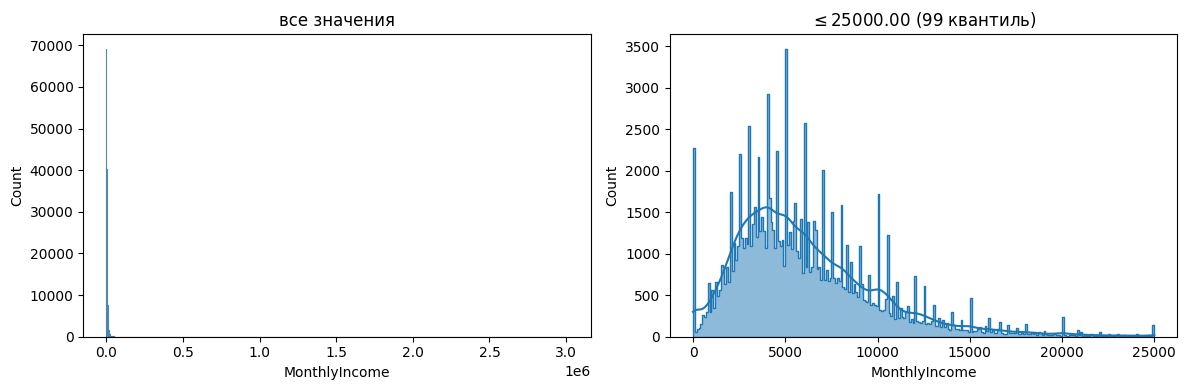

In [34]:
fix, axs = plt.subplots(1, 2, figsize=(12, 4))

quantile_99 = train.MonthlyIncome.quantile(0.99)

sns.histplot(data=train,
             x='MonthlyIncome',
             bins=500,
             ax=axs[0]);
axs[0].set_title('все значения')

sns.histplot(data=train.loc[train.MonthlyIncome.le(quantile_99)],
             x='MonthlyIncome',
             bins=250,
             element='step',
             kde=True,
             ax=axs[1]);
axs[1].set_title(rf'$\leq {quantile_99:.2f}$ (99 квантиль)')

plt.tight_layout()

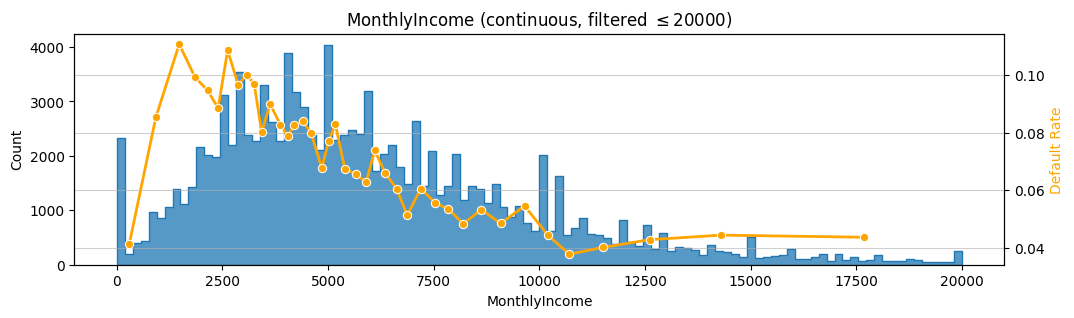

In [35]:
plot_feature_analysis(train, 'MonthlyIncome', max_value=20000,
                      n_quantiles=40, figsize=(12, 3));

#### **~ Гипотеза 2 частично подтверждена**

Полученное распределение частично подтверждает вторую гипотезу, риск дефолта у клиентов с высоким заработком действительно ниже, но ниже дохода в ~1500 у.е. риск дефолта растет.

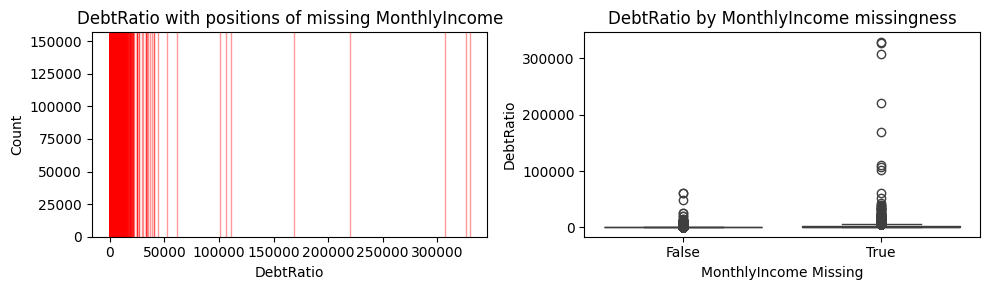

In [36]:
df = train[train.DebtRatio.notna()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(df.DebtRatio, bins=50, kde=False, color='lightblue', ax=axes[0])

missing_DR = df.loc[df.MonthlyIncome.isna(), 'DebtRatio']
for x in missing_DR:
    axes[0].axvline(x=x, color='red', alpha=0.4, linewidth=1)
axes[0].set_xlabel('DebtRatio')
axes[0].set_ylabel('Count')
axes[0].set_title('DebtRatio with positions of missing MonthlyIncome')

df_plot = df.copy()
df_plot['Income_Missing'] = df_plot.MonthlyIncome.isna()

sns.boxplot(data=df_plot, y='DebtRatio', x='Income_Missing', ax=axes[1])
axes[1].set_xlabel('MonthlyIncome Missing')
axes[1].set_ylabel('DebtRatio')
axes[1].set_title('DebtRatio by MonthlyIncome missingness')

plt.tight_layout()
plt.show()

In [37]:
DR_max_income_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio'].max()
print(f"Максимальный DebtRatio с MonthlyIncome notna: {DR_max_income_notna}")

Максимальный DebtRatio с MonthlyIncome notna: 61106.5


In [38]:
print(f"Клиенты с DebtRatio > {DR_max_income_notna}:")
train.loc[train.DebtRatio.gt(DR_max_income_notna), 'SeriousDlqin2yrs']

Клиенты с DebtRatio > 61106.5:


4855      0
7514      0
36601     0
58901     0
60153     0
66786     0
69846     0
103042    0
127048    0
Name: SeriousDlqin2yrs, dtype: int64

Мода DebtRatio с MonthlyIncome.notna(): 0.34
Мода DebtRatio с MonthlyIncome.isna():  1995.73
Мода DebtRatio с MonthlyIncome == 0:    1500.28


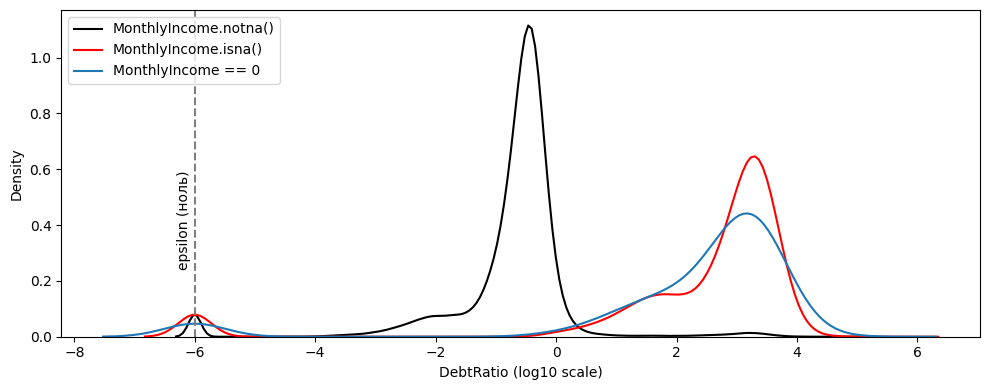

In [39]:
x_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio']
x_isna  = train.loc[train.MonthlyIncome.isna(),  'DebtRatio']
x_zero  = train.loc[train.MonthlyIncome.eq(0),   'DebtRatio']

def get_mode(ax, idx):
    xs = ax.get_lines()[idx].get_xdata()
    ys = ax.get_lines()[idx].get_ydata()
    return xs[np.argmax(ys)]

fig, ax = plt.subplots(figsize=(10, 4))

epsilon = 1e-6
sns.kdeplot(x=np.log10(x_notna + epsilon), ax=ax, color='black', label='MonthlyIncome.notna()')
sns.kdeplot(x=np.log10(x_isna  + epsilon), ax=ax, color='red',   label='MonthlyIncome.isna()')
sns.kdeplot(x=np.log10(x_zero  + epsilon), ax=ax,                label='MonthlyIncome == 0')

plt.axvline(x=np.log10(epsilon), color='gray', linestyle='--')
plt.text(np.log10(epsilon)-0.3, 0.25, 'epsilon (ноль)', rotation=90)

print(f"Мода DebtRatio с MonthlyIncome.notna(): {10 ** get_mode(ax, 0):.2f}")
print(f"Мода DebtRatio с MonthlyIncome.isna():  {10 ** get_mode(ax, 1):.2f}")
print(f"Мода DebtRatio с MonthlyIncome == 0:    {10 ** get_mode(ax, 2):.2f}")

ax.legend(loc='upper left')
ax.set_xlabel('DebtRatio (log10 scale)')
plt.tight_layout()
plt.show()

#### **Гипотеза 4 подтверждена**

Распределения плотностей нулевых и пропущенных значений `MonthlyIncome` действительно коррелируют. При предобработке признаков имеет смысл заменить пропущенные значения нулями.

In [40]:
missing_income_DR_gt_1   = train.loc[train.DebtRatio.gt(1)   & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_10  = train.loc[train.DebtRatio.gt(10)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_50  = train.loc[train.DebtRatio.gt(50)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_451 = train.loc[train.DebtRatio.gt(451) & train.MonthlyIncome.isna(), 'DebtRatio'].count()

print(f"Пропусков при DebtRatio > 1:   {missing_income_DR_gt_1} ({100 * missing_income_DR_gt_1 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 10:  {missing_income_DR_gt_10} ({100 * missing_income_DR_gt_10 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 50:  {missing_income_DR_gt_50} ({100 * missing_income_DR_gt_50 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 451: {missing_income_DR_gt_451} ({100 * missing_income_DR_gt_451 / missing_income:.2f}%)")

Пропусков при DebtRatio > 1:   27904 (93.85%)
Пропусков при DebtRatio > 10:  26771 (90.04%)
Пропусков при DebtRatio > 50:  24138 (81.19%)
Пропусков при DebtRatio > 451: 19674 (66.17%)


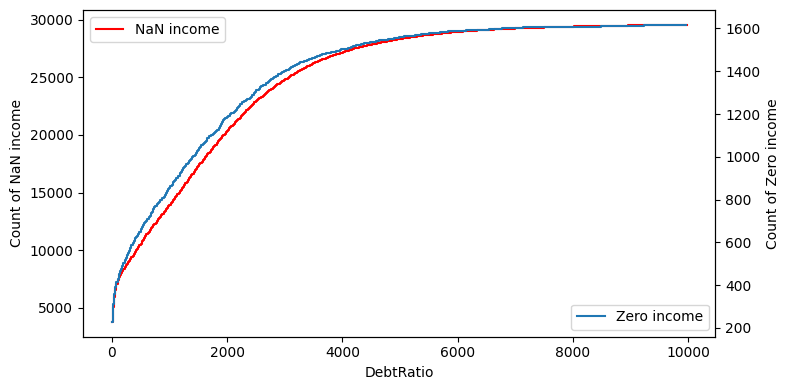

In [41]:
missing_income = train.loc[train.MonthlyIncome.isna() & train.DebtRatio.between(0, 10000), 'DebtRatio']
zero_income = train.loc[train.MonthlyIncome.eq(0) & train.DebtRatio.between(0, 10000), 'DebtRatio']

fig, ax1 = plt.subplots(figsize=(8, 4))

sns.histplot(missing_income, bins=500, cumulative=1, element="step", color='red', fill=False, ax=ax1, label='NaN income')
plt.ylabel('Count of NaN income')
ax1.legend()

ax2=ax1.twinx()

sns.histplot(zero_income, bins=500, cumulative=1, element="step", fill=False, ax=ax2, label='Zero income')
plt.ylabel('Count of Zero income')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

## `NumberOfDependents`

In [42]:
missing_count = train.NumberOfDependents.isna().sum()
missing_pct   = train.NumberOfDependents.isna().mean() * 100

print(f"Количество пропусков: {missing_count:.2f} ({missing_pct:.2f}%)")
train.NumberOfDependents.describe()

Количество пропусков: 3924.00 (2.62%)


count    146076.000000
mean          0.757222
std           1.115086
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

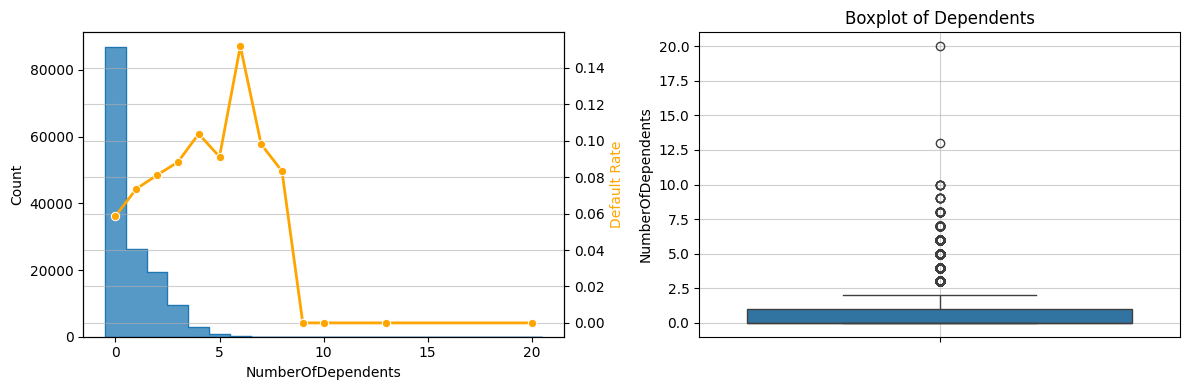

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train, 'NumberOfDependents', discrete=True,
                      title='', ax=axs[0])

sns.boxplot(data=train, y='NumberOfDependents', ax=axs[1])
axs[1].set_title('Boxplot of Dependents')
axs[1].grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

#### **~ Гипотеза 3.1 частично подтверждена**

Полученное распределение частично подтверждает гипотезу 3.1, прямая зависимость между количеством иждивенцев и риском дефолта действительно существует, однако при 7 и более иждивенцах наблюдается спад риска дефолта.

In [44]:
(train.groupby('NumberOfDependents')
    .agg(
        Count=('NumberOfDependents', 'size'),
        DefaultRate=('SeriousDlqin2yrs', 'mean')
    )
    .assign(
        Percent=lambda x: (x['Count'] / x['Count'].sum()) * 100,
        CumPercent=lambda x: x['Percent'].cumsum(),
        RevCumPercent=lambda x: x['Percent'].iloc[::-1].cumsum().iloc[::-1]
    )
)

,Count,DefaultRate,Percent,CumPercent,RevCumPercent
NumberOfDependents,,,,,
0.0,86902,0.058629,59.490950,59.490950,100.000000
1.0,26316,0.073529,18.015280,77.506230,40.509050
2.0,19522,0.081139,13.364276,90.870506,22.493770
3.0,9483,0.088263,6.491826,97.362332,9.129494
4.0,2862,0.103774,1.959254,99.321586,2.637668
5.0,746,0.091153,0.510693,99.832279,0.678414
6.0,158,0.151899,0.108163,99.940442,0.167721
7.0,51,0.098039,0.034913,99.975355,0.059558
8.0,24,0.083333,0.016430,99.991785,0.024645


## `NumberOfOpenCreditLinesAndLoans`

In [45]:
train.NumberOfOpenCreditLinesAndLoans.describe()

count    150000.000000
mean          8.452760
std           5.145951
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

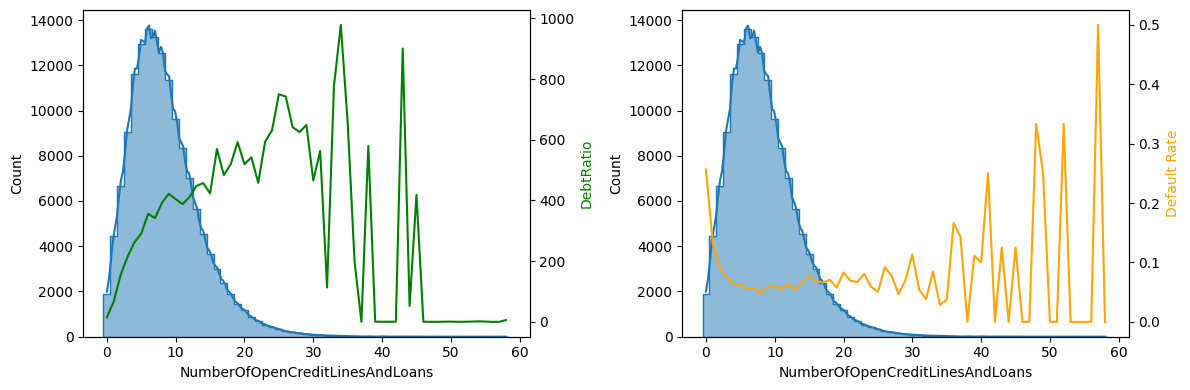

In [46]:
default_rate = train.groupby('NumberOfOpenCreditLinesAndLoans').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberOfOpenCreditLinesAndLoans').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train, x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, kde=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

sns.histplot(data=train, x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, kde=True, ax=axs[1]);
ax2 = axs[1].twinx()
sns.lineplot(data=default_rate, color='orange', ax=ax2);
ax2.yaxis.label.set_color('orange')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

#### **✘ Гипотеза 3.4 опровергнута**

Полученное распределение опровергает гипотезу 3.4. На самом деле с увеличением количества заемов до ~7 риск дефолта стремительно уменьшается и выходит на плато с небольшим восходящим трендом.

In [47]:
counts = train.groupby('NumberOfOpenCreditLinesAndLoans').size()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberOfOpenCreditLinesAndLoans,,,
0,1888,0.256356,15.161704
1,4438,0.131816,67.434211
2,6666,0.091359,155.001760
3,9058,0.075293,214.554490
4,11609,0.064002,262.078596
5,12931,0.063336,291.429694
6,13614,0.055384,355.996270
7,13245,0.056399,342.164066
8,12562,0.048241,392.206381


In [48]:
100 * train.NumberOfOpenCreditLinesAndLoans.le(26).mean()

np.float64(99.4)

In [49]:
stats.reset_index().iloc[:26].corr()

,NumberOfOpenCreditLinesAndLoans,Count,DefaultRate,AvgDebtRatio
NumberOfOpenCreditLinesAndLoans,1.000000,-0.701014,-0.404872,0.926523
Count,-0.701014,1.000000,-0.260755,-0.452135
DefaultRate,-0.404872,-0.260755,1.000000,-0.615583
AvgDebtRatio,0.926523,-0.452135,-0.615583,1.000000


## `NumberRealEstateLoansOrLines`

In [50]:
train.NumberRealEstateLoansOrLines.describe()

count    150000.000000
mean          1.018240
std           1.129771
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

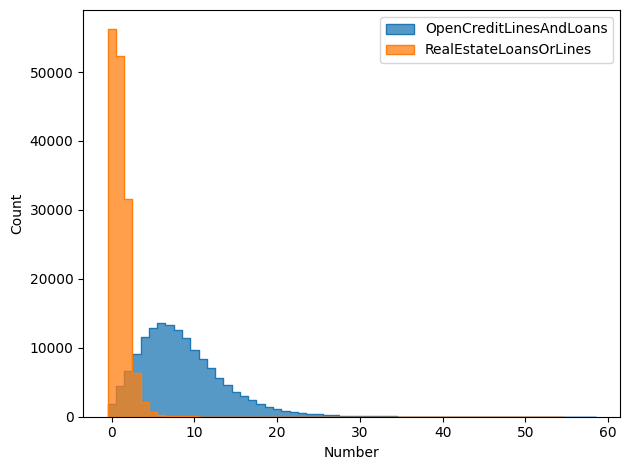

In [51]:
sns.histplot(data=train,   x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, label='OpenCreditLinesAndLoans');
ax = sns.histplot(data=train, x='NumberRealEstateLoansOrLines', element='step', discrete=True, label='RealEstateLoansOrLines');
ax.set_xlabel('Number')
plt.legend()

plt.tight_layout()

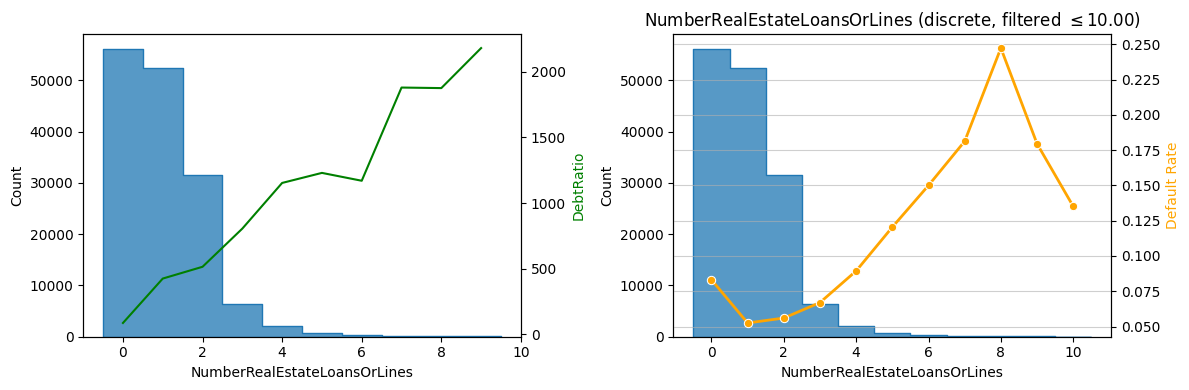

In [52]:
default_rate = train.groupby('NumberRealEstateLoansOrLines').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberRealEstateLoansOrLines').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

threshold = 10

sns.histplot(data=train.loc[train.NumberRealEstateLoansOrLines.lt(threshold)],
             x='NumberRealEstateLoansOrLines',
             element='step',
             discrete=True, 
             ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio.iloc[:threshold], color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

plot_feature_analysis(train, 'NumberRealEstateLoansOrLines', max_value=threshold, discrete=True, ax=axs[1])

plt.tight_layout()

#### **✔ Гипотеза 5 подтверждена**

Полученное распределение подтверждает пятую гипотезу, риск дефолта у клиентов с 1-3 займами на недвижимость действительно ниже, чем у клиентов вообще без займов и у клиентов с 4 и более займами.

In [53]:
counts = train.groupby('NumberRealEstateLoansOrLines').size()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberRealEstateLoansOrLines,,,
0,56188,0.083149,85.652414
1,52338,0.052505,424.164033
2,31522,0.055993,514.044291
3,6300,0.066984,805.115425
4,2170,0.089401,1153.162134
5,689,0.120464,1229.723482
6,320,0.150000,1169.786602
7,171,0.181287,1880.300392
8,93,0.247312,1876.135471


In [54]:
stats.reset_index().iloc[:5].corr()

,NumberRealEstateLoansOrLines,Count,DefaultRate,AvgDebtRatio
NumberRealEstateLoansOrLines,1.000000,-0.970022,0.262086,0.986195
Count,-0.970022,1.000000,-0.328271,-0.932566
DefaultRate,0.262086,-0.328271,1.000000,0.290239
AvgDebtRatio,0.986195,-0.932566,0.290239,1.000000


In [55]:
train.NumberRealEstateLoansOrLines.quantile(0.99)

np.float64(4.0)

In [56]:
100 * train.NumberRealEstateLoansOrLines.le(4).mean()

np.float64(99.012)

## `NumberOfTime30-59DaysPastDueNotWorse`

In [57]:
train['NumberOfTime30-59DaysPastDueNotWorse'].describe(percentiles=[0.25, 0.5, 0.75, 0.99, 0.998])

count    150000.000000
mean          0.421033
std           4.192781
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
99%           4.000000
99.8%         8.000000
max          98.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

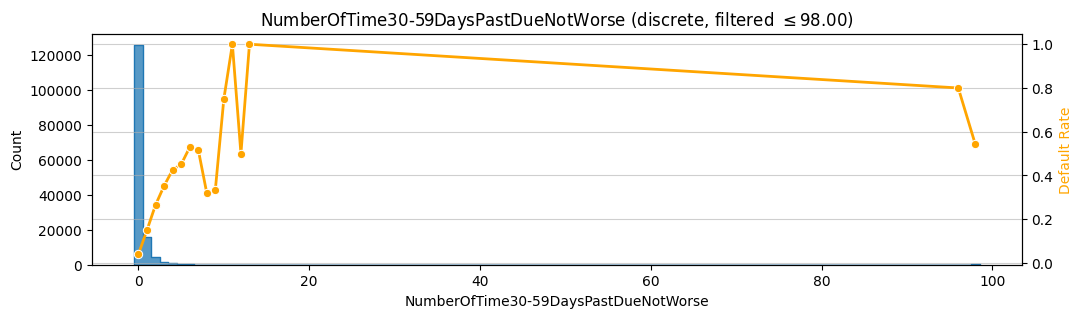

In [58]:
plot_feature_analysis(train, 'NumberOfTime30-59DaysPastDueNotWorse', discrete=True, figsize=(12, 3));

Вероятно значения `96` и `98` являются какими-то банковскими кодами

Риск дефолта монотонно увеличивается с ростом количества просрочек, однако на больших значениях (~9+) наблюдается небольшое падание риска. Такое поведение может объясняться малой плотностью данных (99.8 процентиль = 8).

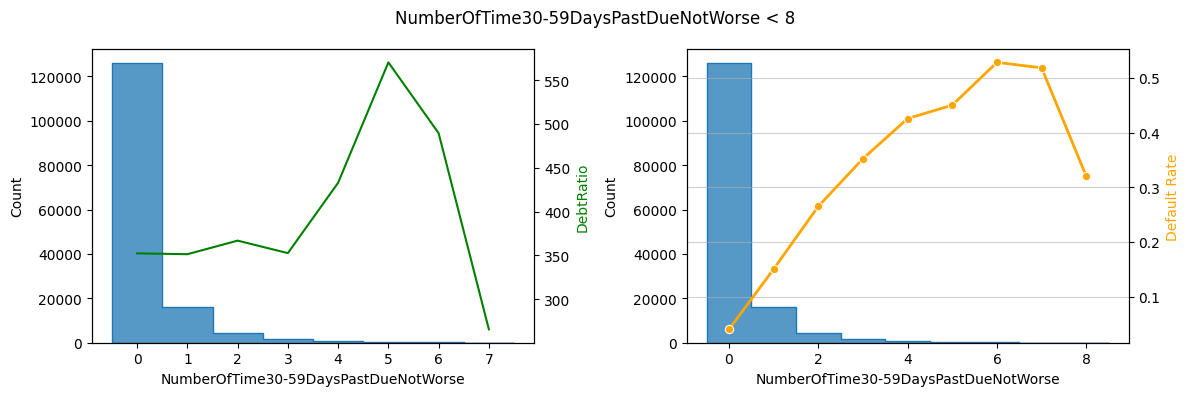

In [59]:
default_rate = train.groupby('NumberOfTime30-59DaysPastDueNotWorse').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberOfTime30-59DaysPastDueNotWorse').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

threshold = 8

sns.histplot(data=train.loc[train['NumberOfTime30-59DaysPastDueNotWorse'].lt(threshold)], x='NumberOfTime30-59DaysPastDueNotWorse', element='step', discrete=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio.iloc[:threshold], color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

plot_feature_analysis(train, 'NumberOfTime30-59DaysPastDueNotWorse', max_value=threshold, discrete=True,
                      title='', ax=axs[1]);

fig.suptitle(f'NumberOfTime30-59DaysPastDueNotWorse < {threshold}')
plt.tight_layout()

Риск дефолта монотонно увеличивается с ростом количества просрочек, падание риска на больших значениях можно объяснить малой плотностью данных.

In [60]:
counts = train.groupby('NumberOfTime30-59DaysPastDueNotWorse').size()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberOfTime30-59DaysPastDueNotWorse,,,
0,126018,0.040002,352.306764
1,16033,0.150253,351.342500
2,4598,0.265115,366.830505
3,1754,0.352338,352.586413
4,747,0.425703,432.865674
5,342,0.450292,570.256063
6,140,0.528571,489.441688
7,54,0.518519,265.574318
8,25,0.320000,126.065088


Монотонность `DefaultRate` ломается при `NumberOfTime30-59DaysPastDueNotWorse` = 7

In [61]:
stats.reset_index().iloc[:8].corr()

,NumberOfTime30-59DaysPastDueNotWorse,Count,DefaultRate,AvgDebtRatio
NumberOfTime30-59DaysPastDueNotWorse,1.000000,-0.650748,0.968459,0.235869
Count,-0.650748,1.000000,-0.762808,-0.225079
DefaultRate,0.968459,-0.762808,1.000000,0.337283
AvgDebtRatio,0.235869,-0.225079,0.337283,1.000000


## `NumberOfTime60-89DaysPastDueNotWorse`

In [62]:
train['NumberOfTime60-89DaysPastDueNotWorse'].describe(percentiles=[0.25, 0.5, 0.75, 0.99, 0.998])

count    150000.000000
mean          0.240387
std           4.155179
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
99%           2.000000
99.8%         5.000000
max          98.000000
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64

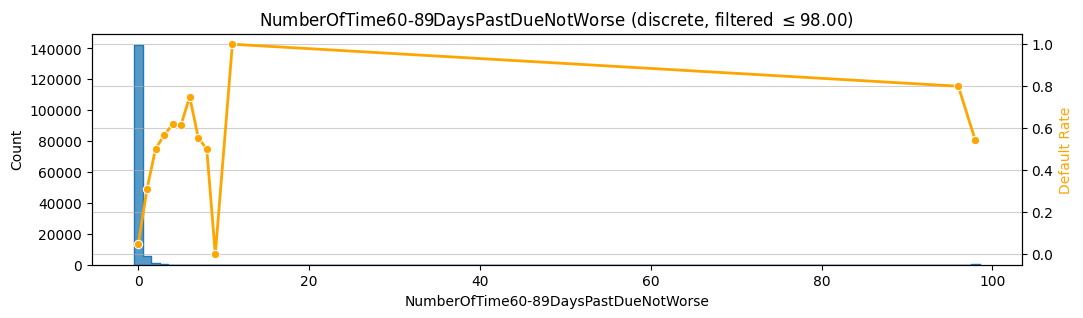

In [63]:
plot_feature_analysis(train, 'NumberOfTime60-89DaysPastDueNotWorse', discrete=True, figsize=(12, 3));

Вероятно значения `96` и `98` являются какими-то банковскими кодами

Риск дефолта монотонно увеличивается с ростом количества просрочек, однако на больших значениях (~8+) наблюдается падание риска. Такое поведение может объясняться малой плотностью данных (99.8 процентиль = 2).

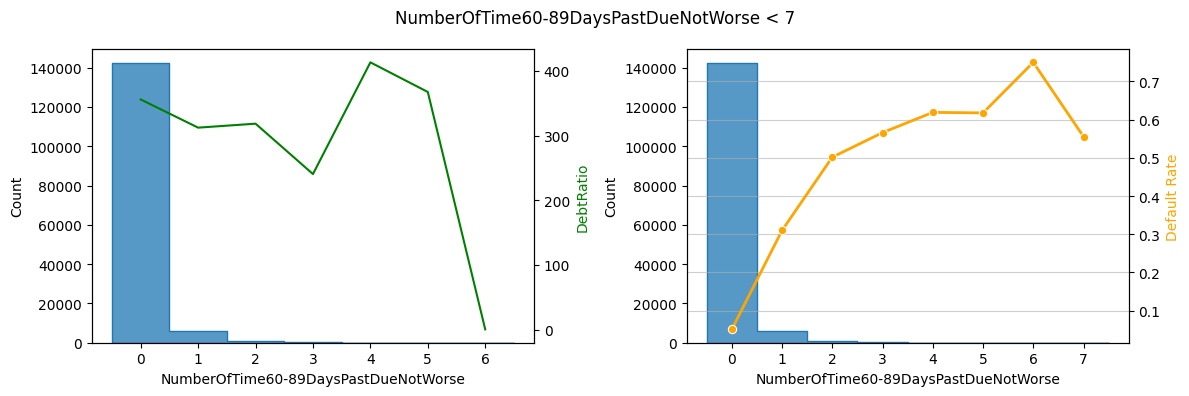

In [64]:
default_rate = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

threshold = 7

sns.histplot(data=train.loc[train['NumberOfTime60-89DaysPastDueNotWorse'].lt(threshold)], x='NumberOfTime60-89DaysPastDueNotWorse', element='step', discrete=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio.iloc[:threshold], color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

plot_feature_analysis(train, 'NumberOfTime60-89DaysPastDueNotWorse',
                      title='', max_value=threshold, discrete=True, figsize=(12, 3), ax=axs[1]);

fig.suptitle(f'NumberOfTime60-89DaysPastDueNotWorse < {threshold}')
plt.tight_layout()

In [65]:
counts = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').size()
default_rate = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').SeriousDlqin2yrs.mean()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberOfTime60-89DaysPastDueNotWorse,,,
0,142396,0.050956,355.810325
1,5731,0.310068,312.241321
2,1118,0.501789,318.384340
3,318,0.566038,240.514616
4,105,0.619048,413.158474
5,34,0.617647,367.370127
6,16,0.750000,0.491469
7,9,0.555556,372.616123
8,2,0.500000,1.362466


In [66]:
stats.reset_index().iloc[:7].corr()

,NumberOfTime60-89DaysPastDueNotWorse,Count,DefaultRate,AvgDebtRatio
NumberOfTime60-89DaysPastDueNotWorse,1.000000,-0.635066,0.928643,-0.484044
Count,-0.635066,1.000000,-0.838856,0.227378
DefaultRate,0.928643,-0.838856,1.000000,-0.443671
AvgDebtRatio,-0.484044,0.227378,-0.443671,1.000000


## `NumberOfTimes90DaysLate`

In [67]:
train.NumberOfTimes90DaysLate.describe(percentiles=[0.25, 0.5, 0.75, 0.99, 0.998])

count    150000.000000
mean          0.265973
std           4.169304
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
99%           3.000000
99.8%         9.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64

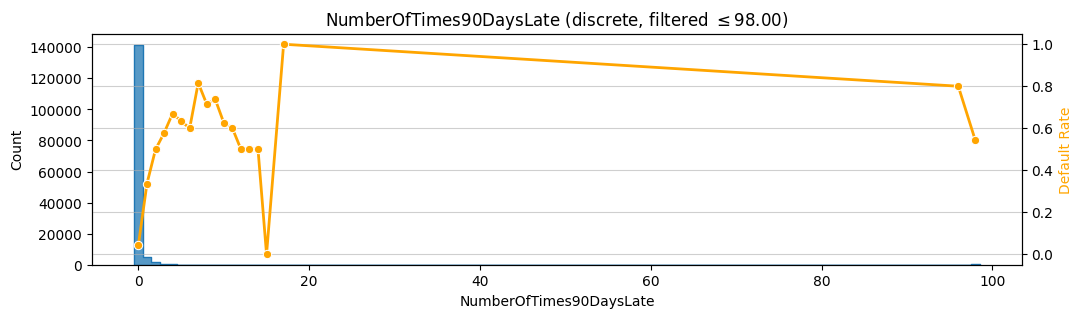

In [68]:
plot_feature_analysis(train, 'NumberOfTimes90DaysLate', discrete=True, figsize=(12, 3));

Вероятно значения `96` и `98` являются какими-то банковскими кодами

Риск дефолта монотонно увеличивается с ростом количества просрочек, однако на больших значениях (~9+) наблюдается падание риска. Такое поведение может объясняться малой плотностью данных (99.8 процентиль = 9).

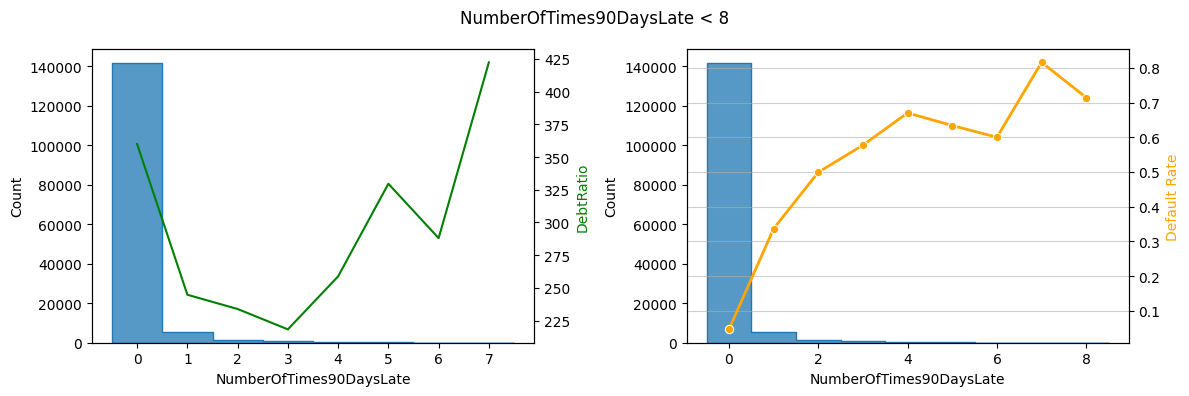

In [69]:
default_rate = train.groupby('NumberOfTimes90DaysLate').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberOfTimes90DaysLate').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

threshold = 8

sns.histplot(data=train.loc[train['NumberOfTimes90DaysLate'].lt(threshold)], x='NumberOfTimes90DaysLate', element='step', discrete=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio.iloc[:threshold], color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

plot_feature_analysis(train, 'NumberOfTimes90DaysLate', max_value=threshold, discrete=True,
                      title='', ax=axs[1])

fig.suptitle(f'NumberOfTimes90DaysLate < {threshold}')
plt.tight_layout()

In [70]:
counts = train.groupby('NumberOfTimes90DaysLate').size()
default_rate = train.groupby('NumberOfTimes90DaysLate').SeriousDlqin2yrs.mean()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberOfTimes90DaysLate,,,
0,141662,0.046265,359.918846
1,5243,0.336639,244.774523
2,1555,0.499035,233.881825
3,667,0.577211,218.325971
4,291,0.670103,258.836800
5,131,0.633588,329.587105
6,80,0.600000,288.030230
7,38,0.815789,422.344987
8,21,0.714286,157.156489


In [71]:
stats.reset_index().iloc[:8].corr()

,NumberOfTimes90DaysLate,Count,DefaultRate,AvgDebtRatio
NumberOfTimes90DaysLate,1.000000,-0.599404,0.888319,0.403829
Count,-0.599404,1.000000,-0.830901,0.359702
DefaultRate,0.888319,-0.830901,1.000000,0.093611
AvgDebtRatio,0.403829,0.359702,0.093611,1.000000


### **Вывод по трем признакам просрочек**

#### **~ Гипотеза 3.5 частично подтверждена**

Полученные зависимости риска дефолта каждой из трёх просрочек имеют явный восходящий тренд на значимой части данных (порядка 99.8%), однако при больших количествах просрочек наблюдается снижение риска, что частично подтверждает гипотезу 3.5.

#### **✔ Гипотеза 6 подтверждена**

Признаки количества просрочек (`NumberOfTime...`) действительно сильно коррелируют с риском дефолта. Коэффициенты корреляции:
 - 0.97 у `NumberOfTime30-59DaysPastDueNotWorse`
 - 0.93 у `NumberOfTime60-89DaysPastDueNotWorse`
 - 0.89 у `NumberOfTimes90DaysLate`

---

## **Insights**

### Целевая переменная

Доля дефолтов составляет **6.68%** — выборка несбалансирована

### Пропущенные значения

- `MonthlyIncome`: **19.82%** пропусков
    
- `NumberOfDependents`: **2.62%** пропусков

### Анализ признаков

#### `RevolvingUtilizationOfUnsecuredLines`:

- Медиана: 0.1542; 99 квантиль: 1.09; максимум: 50708.00
- Два явных пика при 0.00 и 0.99999990, содержащих 7.25% и 6.84% данных соответственно
- Монотонно растущий тренд риска на отрезке \[0, 2\], с пиком 45.54%
- На \(2, 100\] тренд ломается и риск снижается до 29.05%
- При значениях >100 риск падает до ~5%

#### `age`:

- Максимум: 109; медиана: 52
- Есть аномалия: "0 лет", без нуля минимальный возраст 21 годснижается
- Молодые клиенты более склонны к дефолту
- Распределение в целом выглядит нормально :)

#### `DebtRatio`:

- Максимум: 329664.0; медиана: ~0.37
- У 97.96% клиентов с `DebtRatio > 50` (17.30% выборки) и всех с `DebtRatio >= 451` (14.01% выборки) имеем `MonthlyIncome` = 0 или NaN
- Максимальный риск дефолта (~13%) в интервале \(1, 2\]

#### `MonthlyIncome`:

- 19.82% пропусков (29731); медиана: 5400.00; максимум: 3008750.00
- Взаимосвязь с `DebtRatio`:
  - Мода `DebtRatio` при пропущенном доходе: 1995.73
  - Мода `DebtRatio` при нулевом доходе: 1500.28
  - 90.04% пропусков приходится на клиентов с `DebtRatio > 10`
- Распределение количества пропусков и нулевых значений сильно коррелируют

#### `NumberOfDependents`:

- 2.62% пропусков (3924); медиана: 0; максимум: 20
- 97.36% клиентов имеют $\leq 3$ иждивенцев; 0.0011% имеют $\geq 7$ иждивенцев
- Риск дефолта растет с числом иждивенцев, пик 15.19% при 6, затем падает до 0 при 9

#### `NumberOfOpenCreditLinesAndLoans`:

- Средний `DebtRatio` коррелирует с признаком и достигает пика в 749.93 при значении 25
- Максимальный средний риск дефолта (25.64%) при 0
- Риск убывает с ростом значения
- 99.24% клиентов имеют $\leq 25$

#### `NumberRealEstateLoansOrLines`:

- Медиана 1, максимум 54
- 99.01% респондентов имеют $\leq 4$
- Коррелирует с `DebtRatio` и `SeriousDlqin2yrs` (по аналогии с `NumberOfOpenCreditLinesAndLoans`)

#### `NumberOfTime30-59DaysPastDueNotWorse`:

- Медиана 0, максимум 98, пропуски на $[14, 95] \cup \{97\}$ (96 и 98 — возможно, банковские коды)
- Прямая корреляция с риском дефолта, пик 51.85% при 7
- 99.79% респондентов просрочили платежи $\leq 7$ раз

#### `NumberOfTime60-89DaysPastDueNotWorse`:

- Медиана: 0; максимум: 98; пропуски на $[12, 95] \cup \{97\}$
- Прямая корреляция с риском, пик 75.00% при 6
- 99.75% респондентов просрочили платежи $\leq 6$ раз

#### `NumberOfTimes90DaysLate`:

- Медиана: 0; максимум: 98; пропуски на $[18, 95] \cup \{97\}$
- Прямая корреляция с риском, пик 81.58% при 7
- 99.78% респондентов просрочили платежи $\leq 7$ раз